### Paso 1: Planteamiento del problema y recopilación de datos:

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

total_data = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Paso 2: Exploración y Limpieza

In [2]:
total_data.shape

(768, 9)

In [3]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- Existen 768 filas en este dataset 
- Ninguna de las 9 columnas cuenta con valores nulos.
- El data set cuanta con 9 variables numericas, aunque Outcome se puede considerar como categorica.

# Verificamos que no haya duplicados en el dataset

In [4]:
total_data.duplicated().sum()
np.int64(0)
print("Filas duplicadas exactas:", total_data.duplicated().sum())

Filas duplicadas exactas: 0


# Paso 3: Análisis de variables univariantes

- Análicemos a través de histograma el comportamiento de la variable categorica

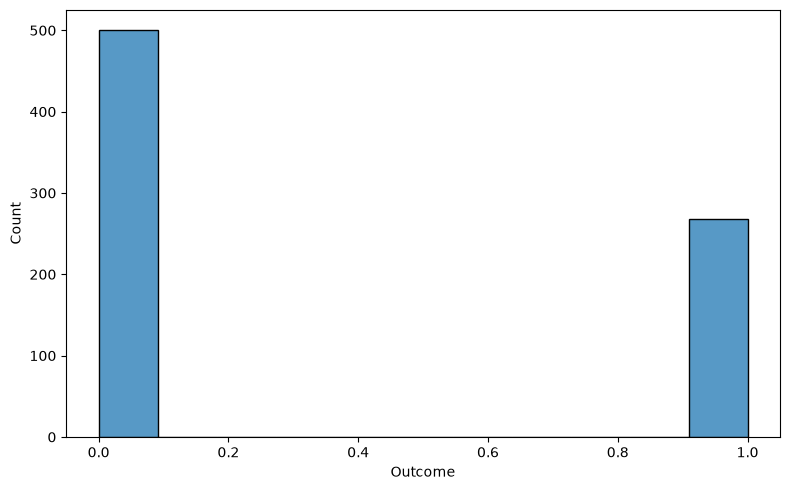

In [5]:
# Crear una única figura sin subplots múltiples
fig, axis = plt.subplots(figsize=(8, 5))

# Crear el histograma
sns.histplot(data = total_data, x = "Outcome", ax = axis)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Podemos detallar que aproximadamente 500 (65%) de los registros no tienen diabetes.
## Análisis sobre variables numéricas:

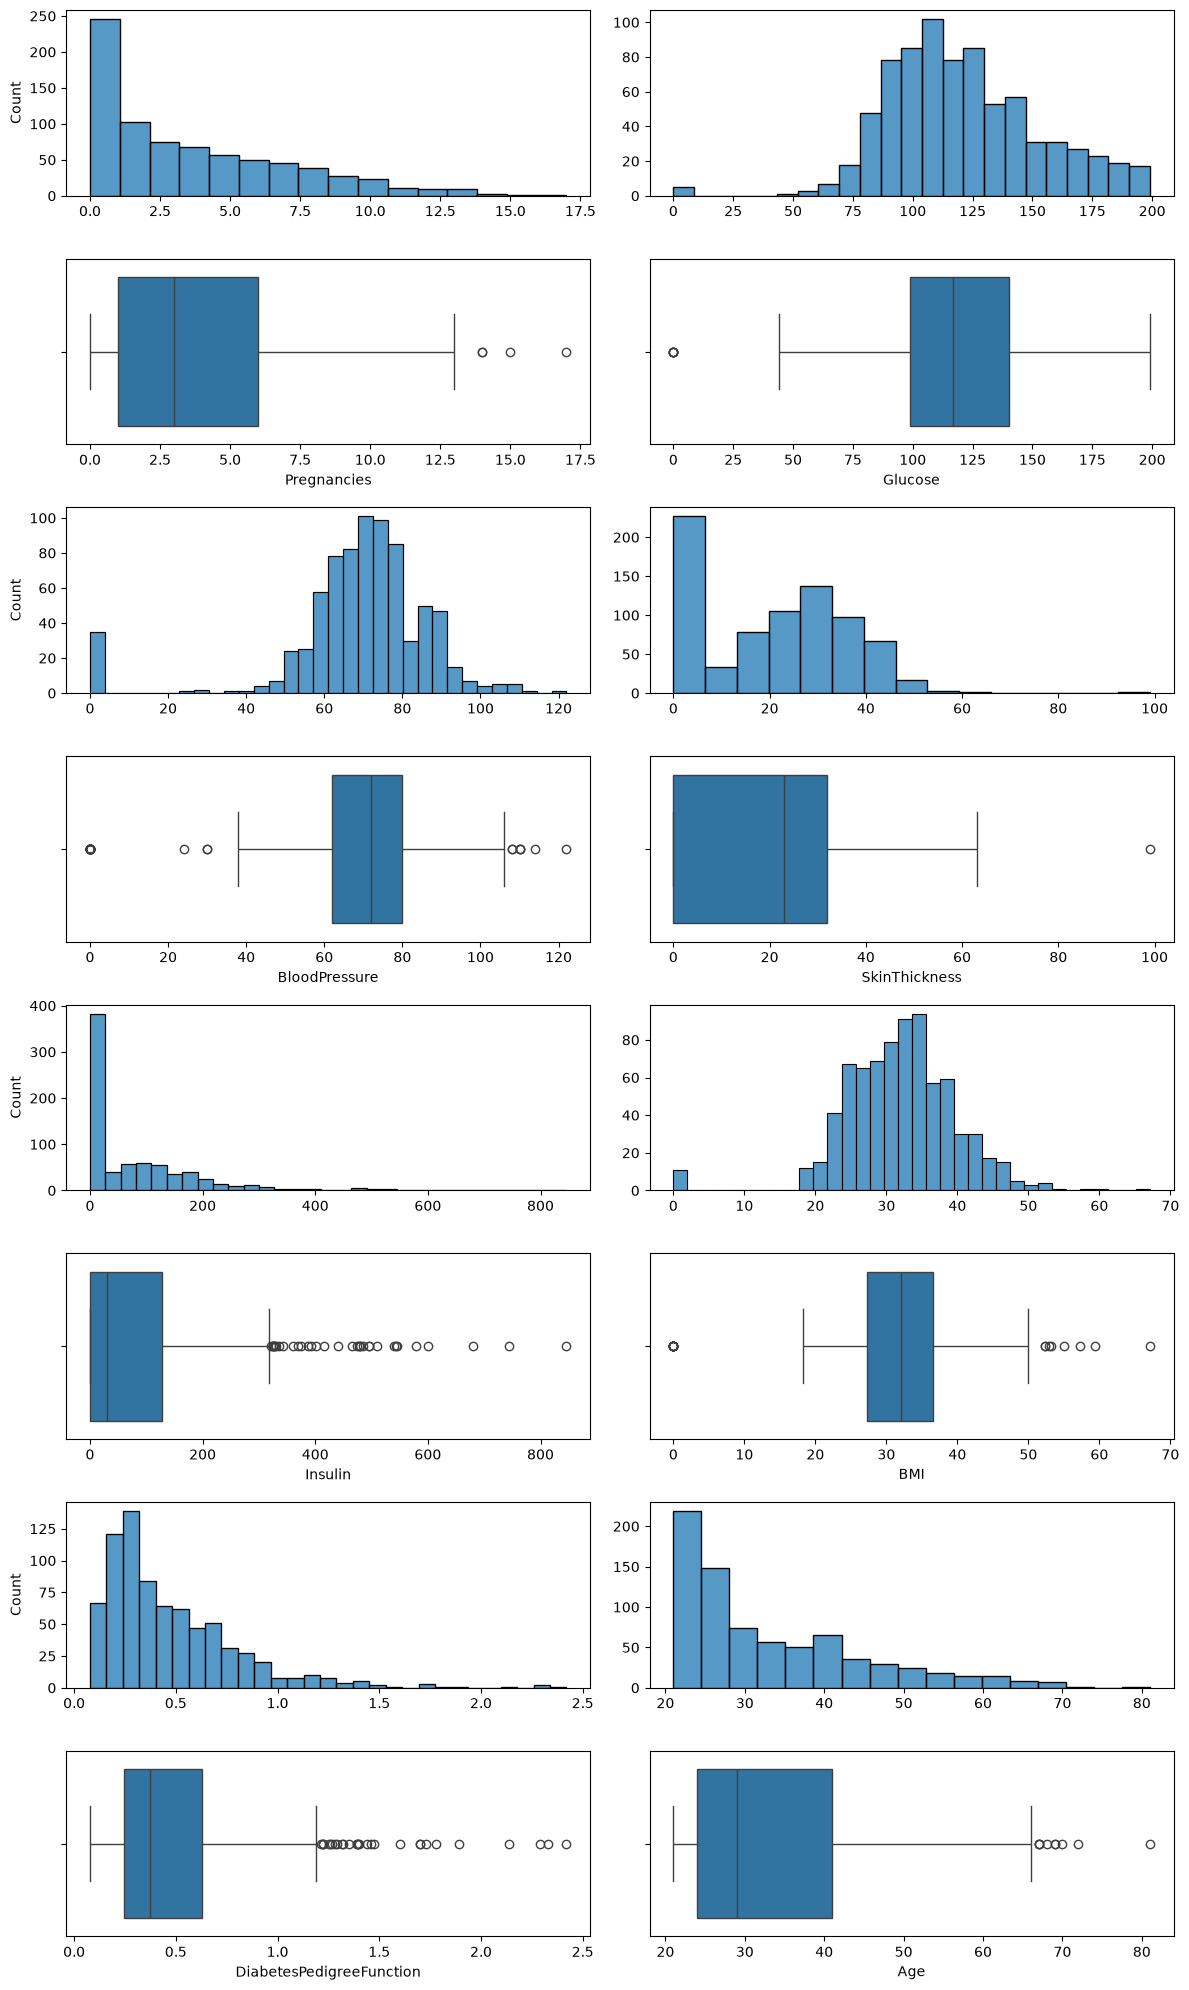

In [6]:
fig, axis = plt.subplots(8, 2, figsize = (12, 20))

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "Pregnancies")
sns.histplot(ax = axis[0, 1], data = total_data, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "Glucose")
sns.histplot(ax = axis[2, 0], data = total_data, x = "BloodPressure").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = total_data, x = "BloodPressure")
sns.histplot(ax = axis[2, 1], data = total_data, x = "SkinThickness").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_data, x = "SkinThickness")
sns.histplot(ax = axis[4, 0], data = total_data, x = "Insulin").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = total_data, x = "Insulin")
sns.histplot(ax = axis[4, 1], data = total_data, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_data, x = "BMI")
sns.histplot(ax = axis[6, 0], data = total_data, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = total_data, x = "DiabetesPedigreeFunction")
sns.histplot(ax = axis[6, 1], data = total_data, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = total_data, x = "Age")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- Notamos que variables como "Glucose", "BloodPressure", "SkinThickness", "Insulin" y "BMI" contienen una cantidad importante de ceros ($0$), lo cual es fisiológicamente imposible para una persona viva, indicando que en realidad son datos faltantes encubiertos.Por lo anterior, primero convertiremos dichos ceros en valores nulos (NaN) para evitar que distorsionen los cálculos, y posteriormente realizaremos una sustitución utilizando la mediana de cada columna.

In [7]:
# Definimos las columnas que contienen ceros fisiológicamente imposibles
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 1. Convertimos los ceros en valores nulos (NaN) para evitar distorsiones
total_data[cols_to_fix] = total_data[cols_to_fix].replace(0, np.nan)

# 2. Calculamos la mediana de cada columna (ignorando los NaN) y realizamos la sustitución
for col in cols_to_fix:
  median_val = total_data[col].median()
  total_data[col] = total_data[col].fillna(median_val)

# Verificamos que ya no queden ceros en estas columnas
print("Ceros restantes por columna:")
print((total_data[cols_to_fix] == 0).sum())

Ceros restantes por columna:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Volvemos a gráficar las variables numéricas con la sustitución

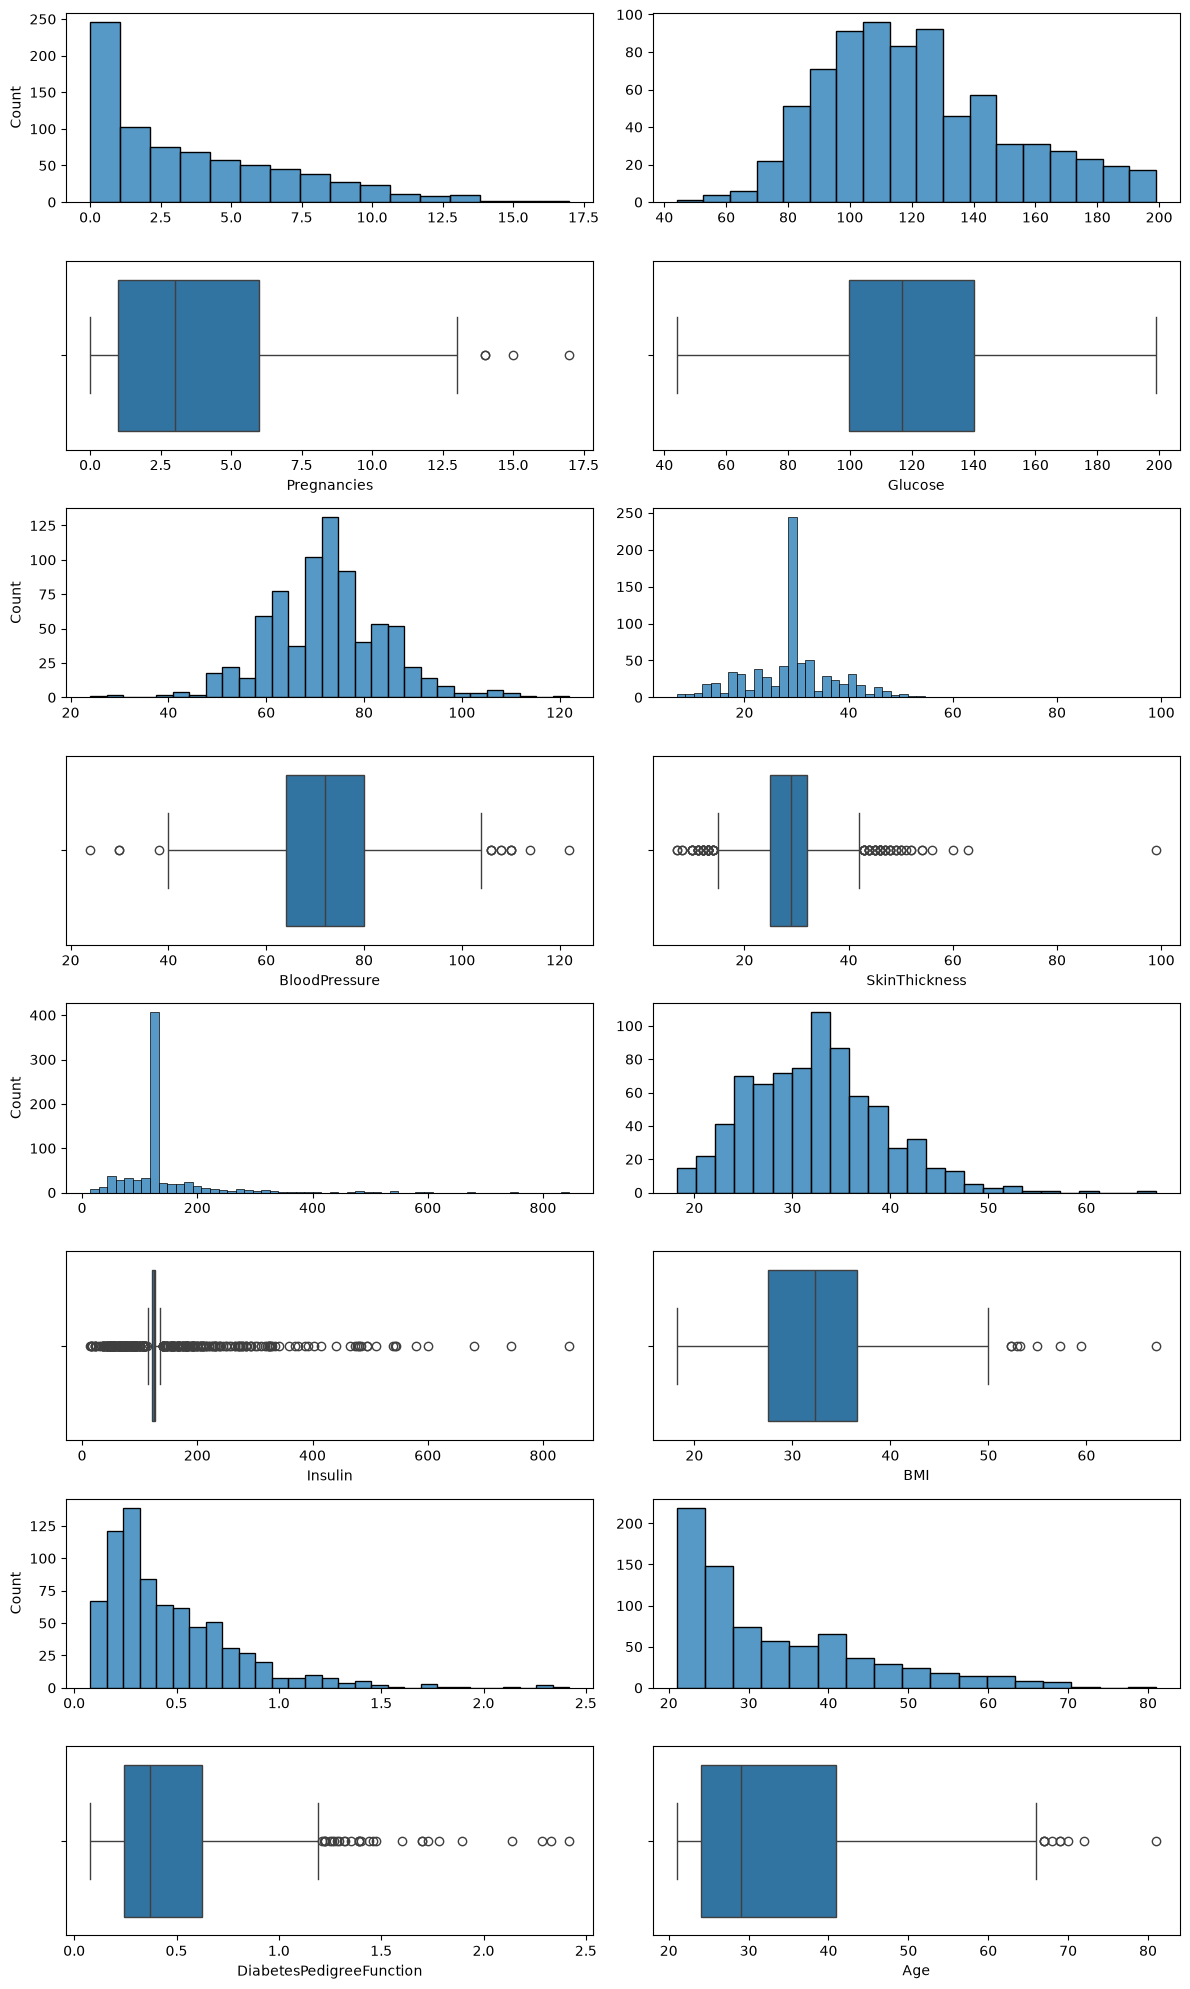

In [8]:
fig, axis = plt.subplots(8, 2, figsize = (12, 20))

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "Pregnancies").set(xlabel = None)
sns.boxplot(ax = axis[1, 0], data = total_data, x = "Pregnancies")
sns.histplot(ax = axis[0, 1], data = total_data, x = "Glucose").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "Glucose")
sns.histplot(ax = axis[2, 0], data = total_data, x = "BloodPressure").set(xlabel = None)
sns.boxplot(ax = axis[3, 0], data = total_data, x = "BloodPressure")
sns.histplot(ax = axis[2, 1], data = total_data, x = "SkinThickness").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[3, 1], data = total_data, x = "SkinThickness")
sns.histplot(ax = axis[4, 0], data = total_data, x = "Insulin").set(xlabel = None)
sns.boxplot(ax = axis[5, 0], data = total_data, x = "Insulin")
sns.histplot(ax = axis[4, 1], data = total_data, x = "BMI").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[5, 1], data = total_data, x = "BMI")
sns.histplot(ax = axis[6, 0], data = total_data, x = "DiabetesPedigreeFunction").set(xlabel = None)
sns.boxplot(ax = axis[7, 0], data = total_data, x = "DiabetesPedigreeFunction")
sns.histplot(ax = axis[6, 1], data = total_data, x = "Age").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[7, 1], data = total_data, x = "Age")

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

- **Pregnancies (Embarazos):** presenta un claro sesgo positivo hacia la derecha. La gran mayoría de los registros se concentran entre 0 y 4 embarazos, con una disminución gradual a medida que aumenta el número, alcanzando valores máximos atípicos superiores a 15.
- **Glucose (Glucosa):** muestra una forma cercana a la distribución normal (campana de Gauss) tras haber eliminado los ceros anómalos. La concentración principal se sitúa en rangos considerados normales/moderados, con una cola derecha que extiende los valores hacia niveles hiperglucémicos.
- **BloodPressure (Presión Sanguínea):** tras limpiar los ceros fisiológicamente imposibles, los valores se agrupan simétricamente en torno a la media/mediana (valores de presión diastólica típicos de la muestra).
- **SkinThickness (Grosor de Piel):** presenta un sesgo positivo marcado con una acumulación de datos en valores bajos y una cola extendida hacia valores altos en el diagrama de caja.
- **Insulin (Insulina):** es la variable que presentaba mayor cantidad de ceros ocultos. Una vez imputada, muestra una distribución fuertemente sesgada a la derecha con una alta densidad de valores en rangos bajos y múltiples puntos atípicos superiores en el boxplot.
- **BMI (Índice de Masa Corporal):** distribución bastante simétrica y acampanada, centrada en rangos de sobrepeso/obesidad según los estándares clínicos, con pocos valores extremos aislados.
- **DiabetesPedigreeFunction (Función de Pedigrí de Diabetes):** muestra un sesgo positivo pronunciado. La gran mayoría de los valores se concentran en la parte baja de la escala, con una cola larga y varios valores atípicos hacia arriba.
- **Age (Edad):** fuerte sesgo positivo. La población del dataset es mayoritariamente joven a de mediana edad (concentrada en el rango inferior), disminuyendo drásticamente la frecuencia en adultos mayores.

## Análisis de variables multivariante:

### Análisis numérico-numérico:

##### Outcome - (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age)

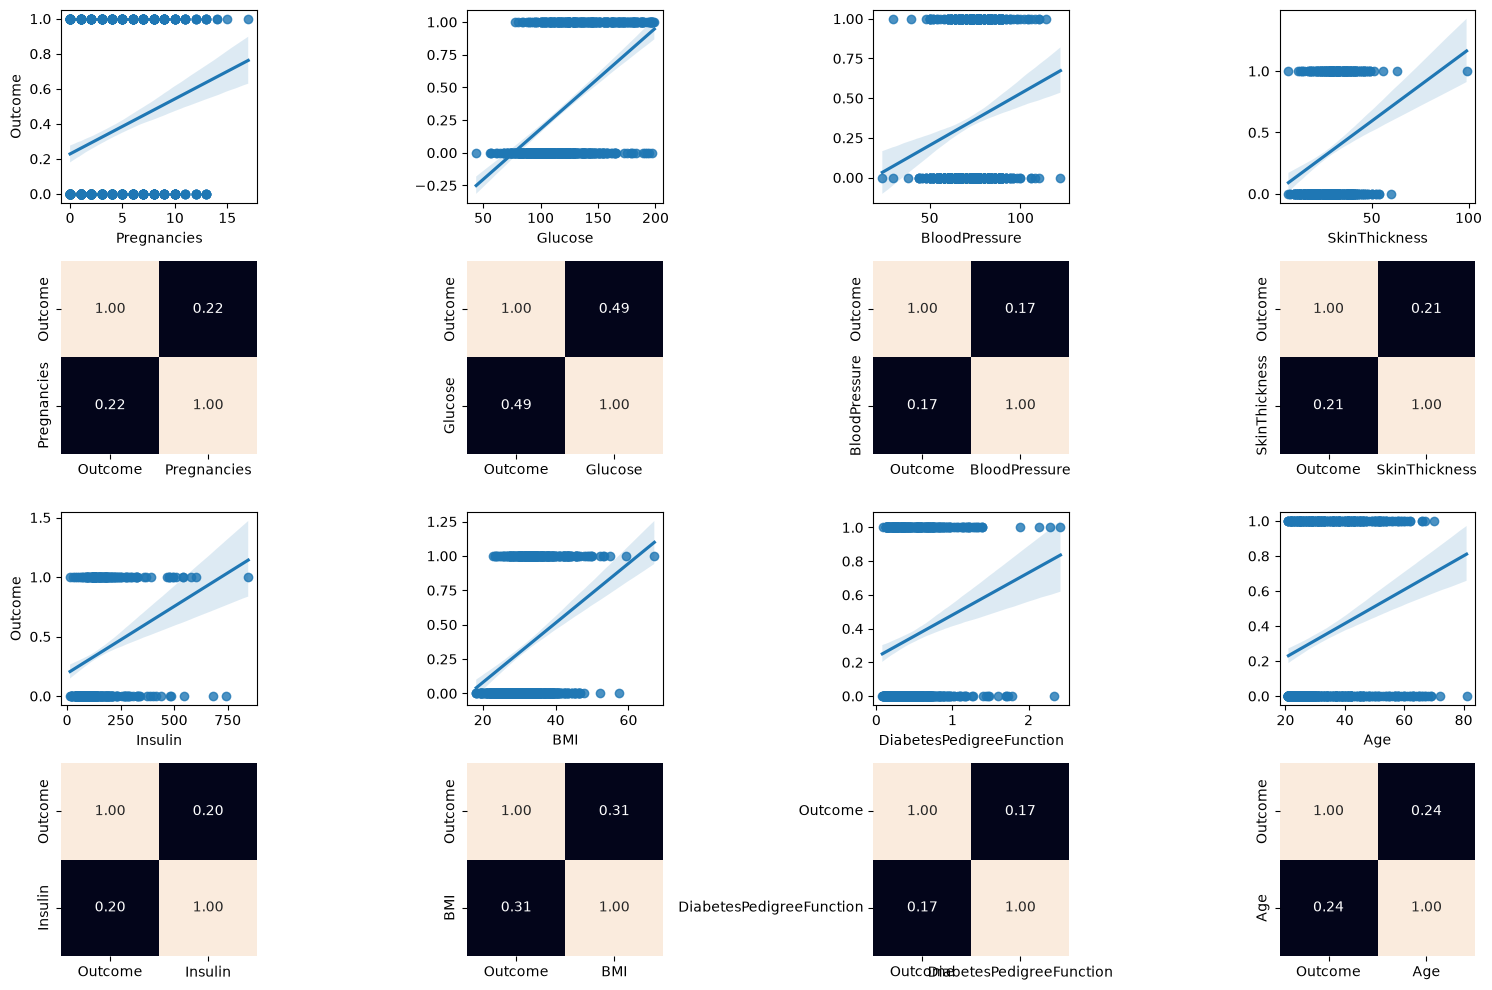

In [9]:
fig, axis = plt.subplots(4, 4, figsize = (15, 10))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "Pregnancies", y = "Outcome")
sns.heatmap(total_data[["Outcome", "Pregnancies"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "Glucose", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "Glucose"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)
sns.regplot(ax = axis[0, 2], data = total_data, x = "BloodPressure", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "BloodPressure"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2], cbar = False)
sns.regplot(ax = axis[0, 3], data = total_data, x = "SkinThickness", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "SkinThickness"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 3], cbar = False)
sns.regplot(ax = axis[2, 0], data = total_data, x = "Insulin", y = "Outcome")
sns.heatmap(total_data[["Outcome", "Insulin"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)
sns.regplot(ax = axis[2, 1], data = total_data, x = "BMI", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "BMI"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)
sns.regplot(ax = axis[2, 2], data = total_data, x = "DiabetesPedigreeFunction", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "DiabetesPedigreeFunction"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 2], cbar = False)
sns.regplot(ax = axis[2, 3], data = total_data, x = "Age", y = "Outcome").set(ylabel=None)
sns.heatmap(total_data[["Outcome", "Age"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 3], cbar = False)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

El análisis conjunto de los diagramas de dispersión y las matrices de correlación revela que la Glucose presenta la relación lineal más fuerte con el diagnóstico de diabetes (Outcome), con un coeficiente de correlación de $0.49$, seguida por variables secundarias como el BMI ($0.33$) y la Age ($0.24$). Por el contrario, factores como BloodPressure y SkinThickness muestran correlaciones notablemente más bajas ($0.17$ y $0.21$, respectivamente), lo que indica que, si bien todas las variables limpiadas aportan contexto biológico al EDA, la glucosa y el índice de masa corporal se perfilan como los predictores cuantitativos más determinantes de cara al posterior entrenamiento del árbol de decisión.

## Análisis de correlaciones:
- Aqui confirmamos lo que comentado en el bloique anterior

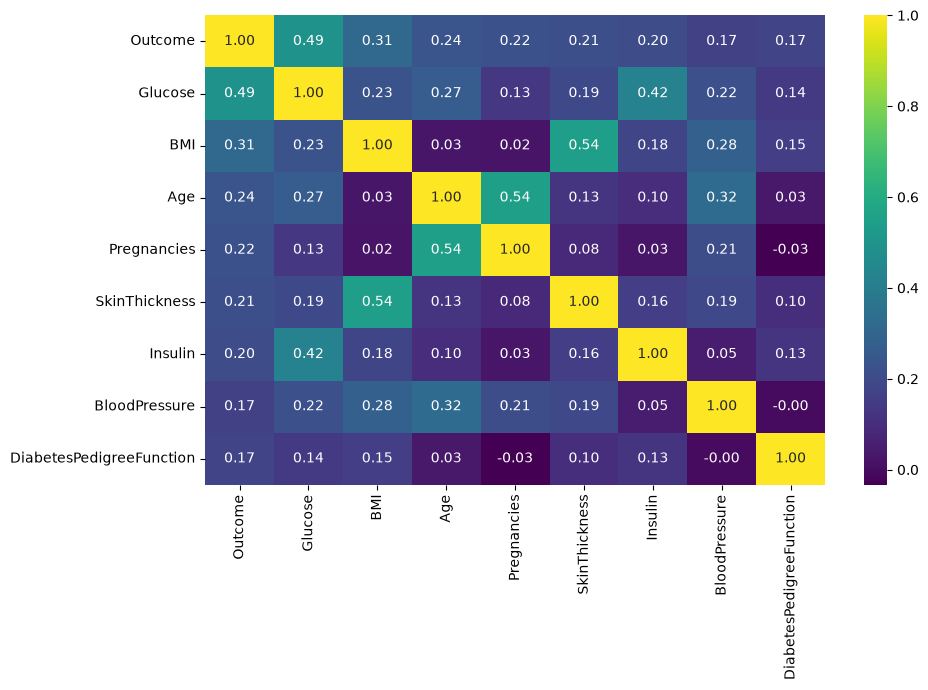

In [10]:
cols_num = ["Outcome", "Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Ingeniería de características:

#### Análisis de outliers:

In [11]:
FINAL_COLS = ["Outcome", "Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]
total_data = total_data[FINAL_COLS]

In [12]:
total_data.columns

Index(['Outcome', 'Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness',
       'Insulin', 'BloodPressure', 'DiabetesPedigreeFunction'],
      dtype='str')

In [13]:
total_data.describe()

,Outcome,Glucose,BMI,Age,Pregnancies,SkinThickness,Insulin,BloodPressure,DiabetesPedigreeFunction
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.348958,121.656250,32.455208,33.240885,3.845052,29.108073,140.671875,72.386719,0.471876
std,0.476951,30.438286,6.875177,11.760232,3.369578,8.791221,86.383060,12.096642,0.331329
min,0.000000,44.000000,18.200000,21.000000,0.000000,7.000000,14.000000,24.000000,0.078000
25%,0.000000,99.750000,27.500000,24.000000,1.000000,25.000000,121.500000,64.000000,0.243750
50%,0.000000,117.000000,32.300000,29.000000,3.000000,29.000000,125.000000,72.000000,0.372500
75%,1.000000,140.250000,36.600000,41.000000,6.000000,32.000000,127.250000,80.000000,0.626250
max,1.000000,199.000000,67.100000,81.000000,17.000000,99.000000,846.000000,122.000000,2.420000


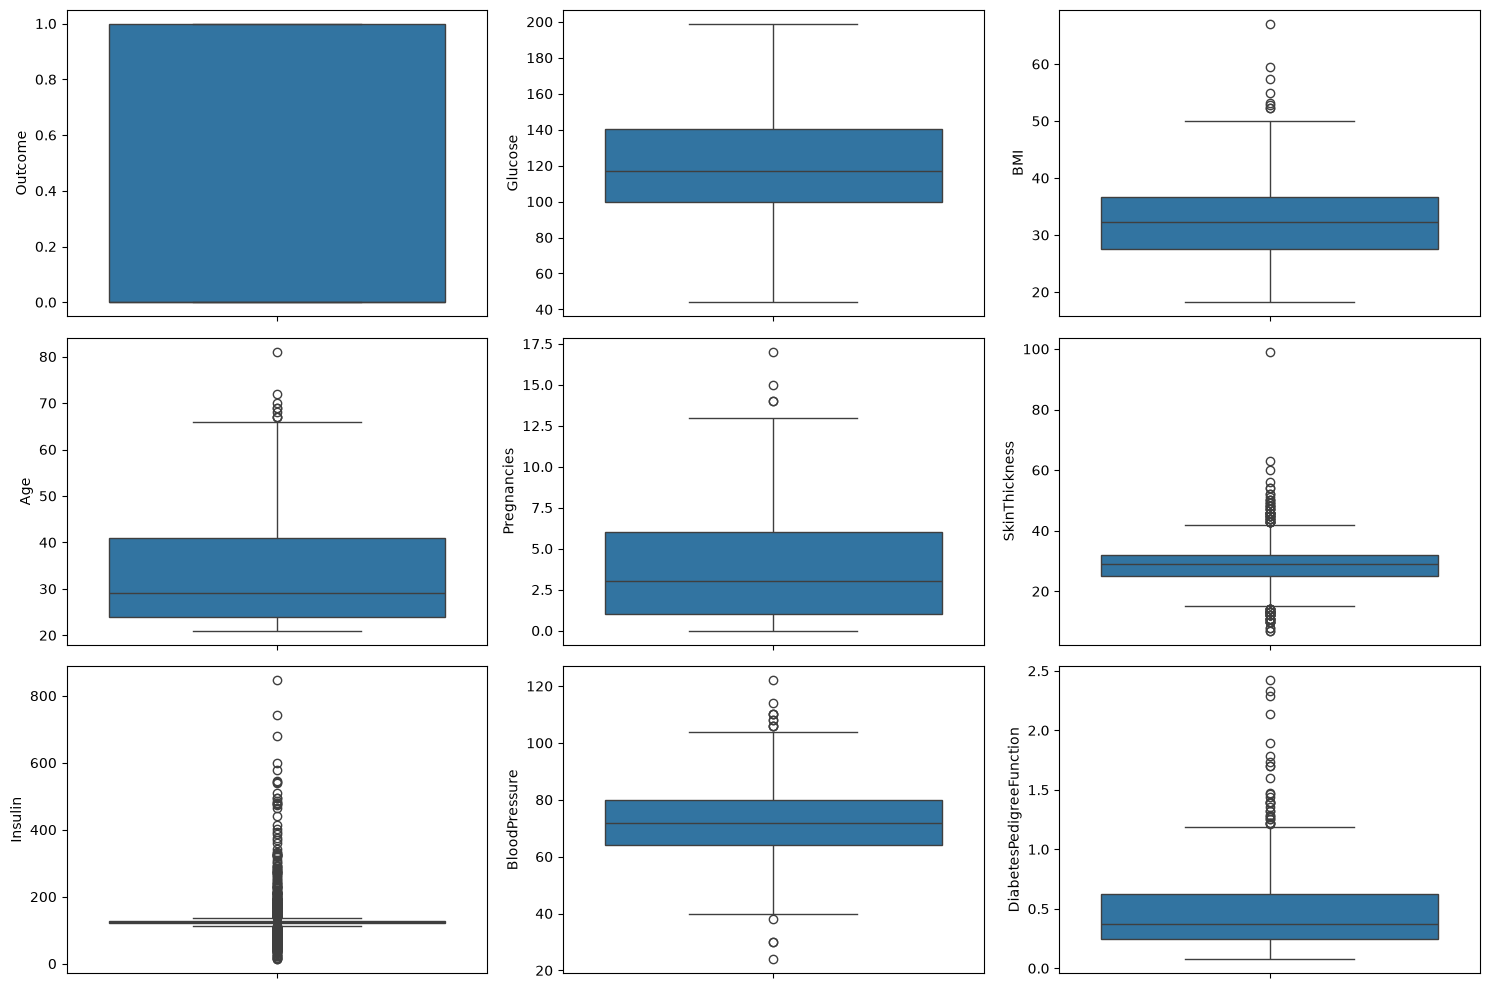

In [14]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = total_data, y = "Outcome")
sns.boxplot(ax = axis[0, 1], data = total_data, y = "Glucose")
sns.boxplot(ax = axis[0, 2], data = total_data, y = "BMI")
sns.boxplot(ax = axis[1, 0], data = total_data, y = "Age")
sns.boxplot(ax = axis[1, 1], data = total_data, y = "Pregnancies")
sns.boxplot(ax = axis[1, 2], data = total_data, y = "SkinThickness")
sns.boxplot(ax = axis[2, 0], data = total_data, y = "Insulin")
sns.boxplot(ax = axis[2, 1], data = total_data, y = "BloodPressure")
sns.boxplot(ax = axis[2, 2], data = total_data, y = "DiabetesPedigreeFunction")

plt.tight_layout()

plt.show()

Por los momentos no vamos a eliminar los valores atípicos, como es un modelo de arboles de decisión éstos son inmunes a los valores atípicos. Un valor extremo simplemente caerá en el nodo final de la rama sin afectar el cálculo de los demás nodos. Si lo eliminamos, lo único que lograremos será perder información valiosa de pacientes reales.
#### Análisis de valores faltantes:

In [15]:
total_data.isnull().sum().sort_values(ascending=False)

Outcome                     0
Glucose                     0
BMI                         0
Age                         0
Pregnancies                 0
SkinThickness               0
Insulin                     0
BloodPressure               0
DiabetesPedigreeFunction    0
dtype: int64

- Ahora definimos nuestras variables predictoras y target

In [16]:
from sklearn.model_selection import train_test_split

# ESTO ES LO QUE ENTRA EN ESTE PASO
# total_data

predictoras = ["Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin", "BloodPressure", "DiabetesPedigreeFunction"]
target = "Outcome"

X_CON = total_data.drop(target, axis = 1)[predictoras]
y = total_data[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)

# ESTO ES LO QUE SALE DE ESTE PASO
# X_train_CON_outliers
# X_test_CON_outliers
# y_train
# y_test

#### Escalado de valores:
- Al ser un modelo de arboles de decisiones no es necesario realizar el escalado de valores.
- Procedemos a guardar los ficheros generados.

In [17]:
# GUARDARLO -> TODO <-

# RECORDAR HABER GUARDADO LOS JSONS DE LA FACTORIZACIÓN

# PATH = "/data/processed"
PATH = "/workspaces/Arbol_de_Decision_Sahid_Leal/data/processed"

# DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
X_train_CON_outliers.to_excel(f"{PATH}/X_train_CON_outliers.xlsx", index = False)

X_test_CON_outliers.to_excel(f"{PATH}/X_test_CON_outliers.xlsx", index = False)


y_train.to_excel(f"{PATH}/y_train.xlsx", index = False)
y_test.to_excel(f"{PATH}/y_test.xlsx", index = False)


### Machine Learning
- Como vamos a trabajar con un modelo de Arbol de decición no tenemos que elegir el mejor dataset ya que solo tenemos un dataset.
- Por otro lado recordemos que solo estamos trabajando con los datos "CON Outliers".

In [18]:
PATH = "/workspaces/Arbol_de_Decision_Sahid_Leal/data/processed"

X_train_CON_outliers = pd.read_excel(f"{PATH}/X_train_CON_outliers.xlsx")
X_test_CON_outliers = pd.read_excel(f"{PATH}/X_test_CON_outliers.xlsx")

y_train = pd.read_excel(f"{PATH}/y_train.xlsx")
y_test = pd.read_excel(f"{PATH}/y_test.xlsx")

## Procedemos a entrenar el modelo y calcular sus métricas:
- Recordemos que el proyecto nos solicita modificar la función de cálculo de la pureza de los nodos, es decir ver la diferencia de criteios: "gini" y "entropy".
- Luego analizamos sus métricas y graficamos los arboles

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Modelo con criterio Gini (por defecto)
model_gini = DecisionTreeClassifier(criterion="gini", random_state=10)
model_gini.fit(X_train_CON_outliers, y_train)

# Predicciones para Train y Test (Gini)
y_train_pred_gini = model_gini.predict(X_train_CON_outliers)
y_pred_gini = model_gini.predict(X_test_CON_outliers)

# 2. Modelo con criterio Entropy
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=10)
model_entropy.fit(X_train_CON_outliers, y_train)

# Predicciones para Train y Test (Entropy)
y_train_pred_entropy = model_entropy.predict(X_train_CON_outliers)
y_pred_entropy = model_entropy.predict(X_test_CON_outliers)

# Resultados comparativos
print("--- Resultados Modelo Gini ---")
print(f"Exactitud en Train: {accuracy_score(y_train, y_train_pred_gini):.4f}")
print(f"Exactitud en Test:  {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Brecha (Train - Test): {(accuracy_score(y_train, y_train_pred_gini) - accuracy_score(y_test, y_pred_gini)):.4f}\n")

print("--- Resultados Modelo Entropy ---")
print(f"Exactitud en Train: {accuracy_score(y_train, y_train_pred_entropy):.4f}")
print(f"Exactitud en Test:  {accuracy_score(y_test, y_pred_entropy):.4f}")
print(f"Brecha (Train - Test): {(accuracy_score(y_train, y_train_pred_entropy) - accuracy_score(y_test, y_pred_entropy)):.4f}")

--- Resultados Modelo Gini ---
Exactitud en Train: 1.0000
Exactitud en Test:  0.7338
Brecha (Train - Test): 0.2662

--- Resultados Modelo Entropy ---
Exactitud en Train: 1.0000
Exactitud en Test:  0.7208
Brecha (Train - Test): 0.2792


-- **Comparativa de Rendimiento:** El criterio Gini obtuvo una exactitud ligeramente superior ($73.38\%$) en comparación con el criterio de Entropía ($72.08\%$).

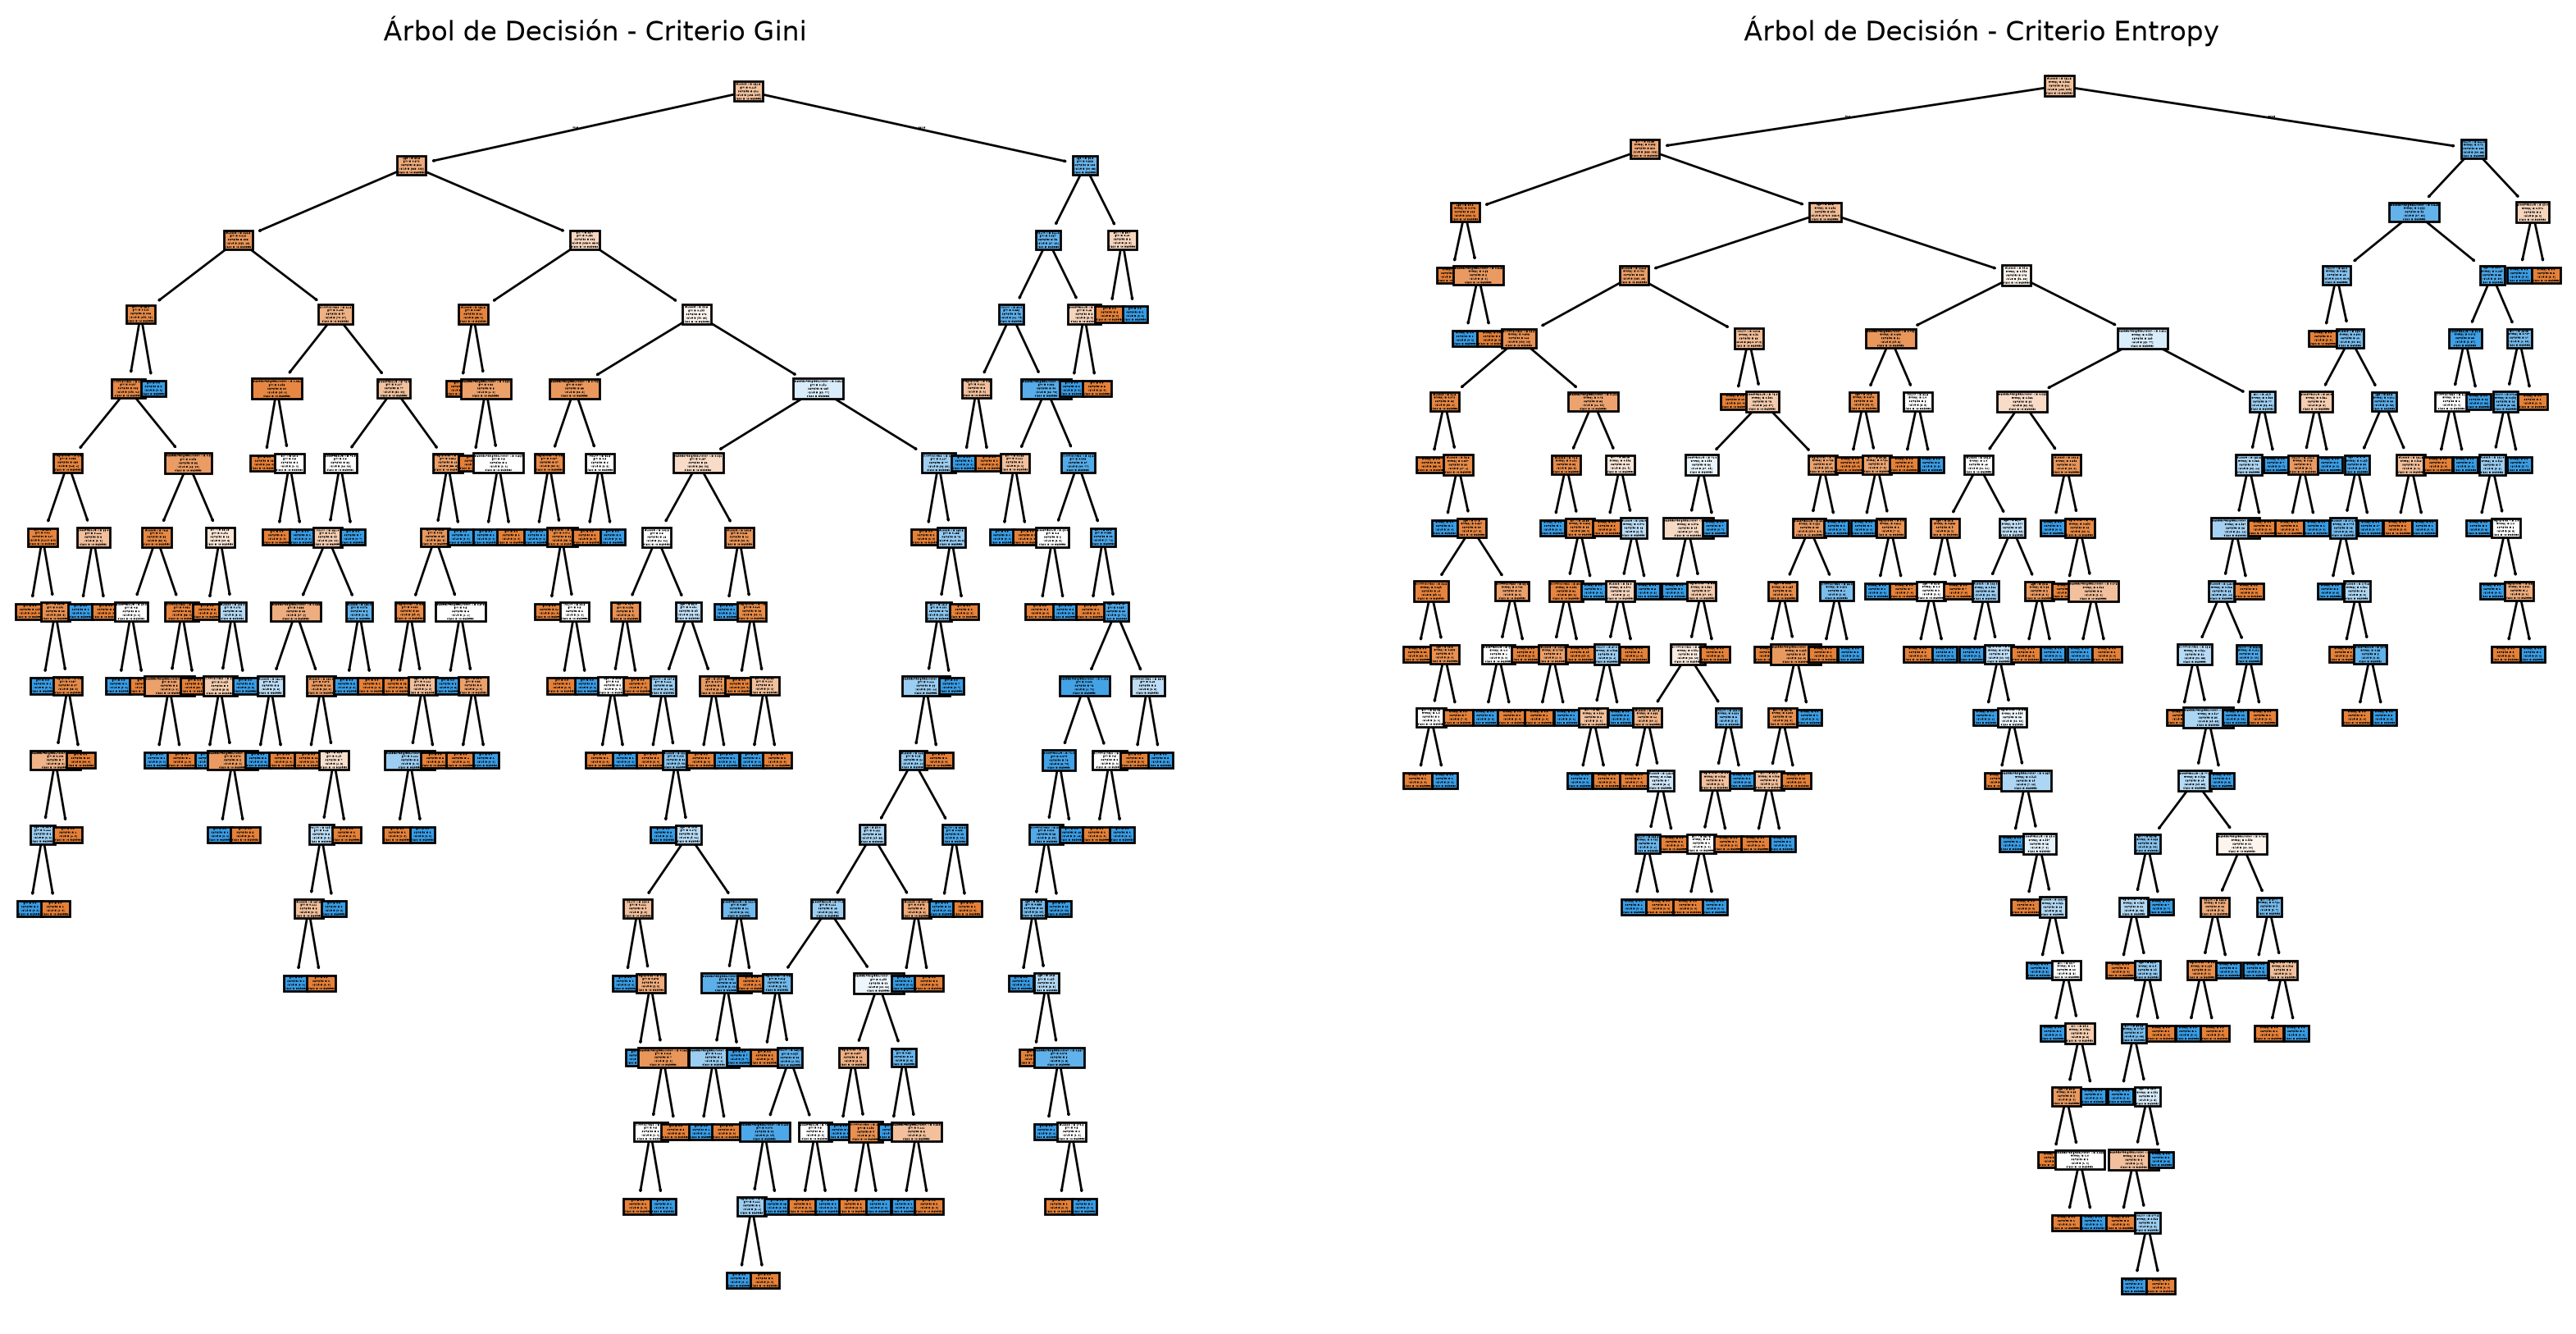

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), dpi=200)

# Graficar el árbol con Gini
plot_tree(model_gini, feature_names=X_train_CON_outliers.columns, 
          class_names=["No Diabetes", "Diabetes"], filled=True, ax=axes[0])
axes[0].set_title("Árbol de Decisión - Criterio Gini")

# Graficar el árbol con Entropy
plot_tree(model_entropy, feature_names=X_train_CON_outliers.columns, 
          class_names=["No Diabetes", "Diabetes"], filled=True, ax=axes[1])
axes[1].set_title("Árbol de Decisión - Criterio Entropy")

plt.show()

- **Visualización:** al graficar ambos árboles se nota que al no tener un límite de profundidad (max_depth), tienden a crecer bastante y volverse complejos (lo que suele generar sobreajuste o overfitting en los datos de entrenamiento).

### Optimiza el modelo anterior:

- Seleccionamos el mejor de los dos arboles (Criterio Gini) y optimizamos sus hiperparámetros principales utilizando un grid search

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Definir el modelo base (seleccionamos Gini por haber obtenido mejor exactitud)
base_model = DecisionTreeClassifier(criterion="gini", random_state=10)

# 2. Configurar una grilla reducida para evitar sobrecargar el kernel
param_grid = {
    "splitter": ["best", "random"],
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_weight_fraction_leaf": [0.0, 0.05, 0.1],
    "max_features": [None, "sqrt", "log2"],
    "max_leaf_nodes": [None, 20, 30],
    "min_impurity_decrease": [0.0, 0.01, 0.05],
    "class_weight": [None, "balanced"],
    "ccp_alpha": [0.0, 0.001, 0.01]
}

# 3. Configurar GridSearchCV con validación cruzada (5 particiones) sin saturar recursos
# n_jobs=1 evita un consumo excesivo de CPU y memoria en el kernel
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=1)

# 4. Ejecutar la búsqueda con los datos de entrenamiento
grid_search.fit(X_train_CON_outliers, y_train)

# 5. Mostrar los mejores hiperparámetros y la mejor exactitud obtenida en validación
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor exactitud (Accuracy) en validación cruzada: {grid_search.best_score_:.4f}")

# 6. Extraer el mejor modelo ya optimizado para usarlo en las pruebas
best_model = grid_search.best_estimator_

Mejores hiperparámetros encontrados:
{'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': 20, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'splitter': 'random'}

Mejor exactitud (Accuracy) en validación cruzada: 0.7785


In [33]:
from sklearn.metrics import accuracy_score

# 6. Extraer el mejor modelo ya optimizado para usarlo en las pruebas
best_model = grid_search.best_estimator_

# 7. Calcular las predicciones para Train y Test
y_train_pred = best_model.predict(X_train_CON_outliers)
y_test_pred = best_model.predict(X_test_CON_outliers)  # Asegúrate de usar el nombre correcto de tu conjunto de test

# 8. Calcular las exactitudes
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# 9. Mostrar los resultados comparativos finales
print("\n--- Rendimiento del Árbol de Decisión Optimizado ---")
print(f"Exactitud en Train: {train_accuracy:.4f}")
print(f"Exactitud en Test:  {test_accuracy:.4f}")
print(f"Brecha (Train - Test): {(train_accuracy - test_accuracy):.4f}")


--- Rendimiento del Árbol de Decisión Optimizado ---
Exactitud en Train: 0.7883
Exactitud en Test:  0.6753
Brecha (Train - Test): 0.1129


## Por último graficamos el arbol con la optimización de hiperparametros:

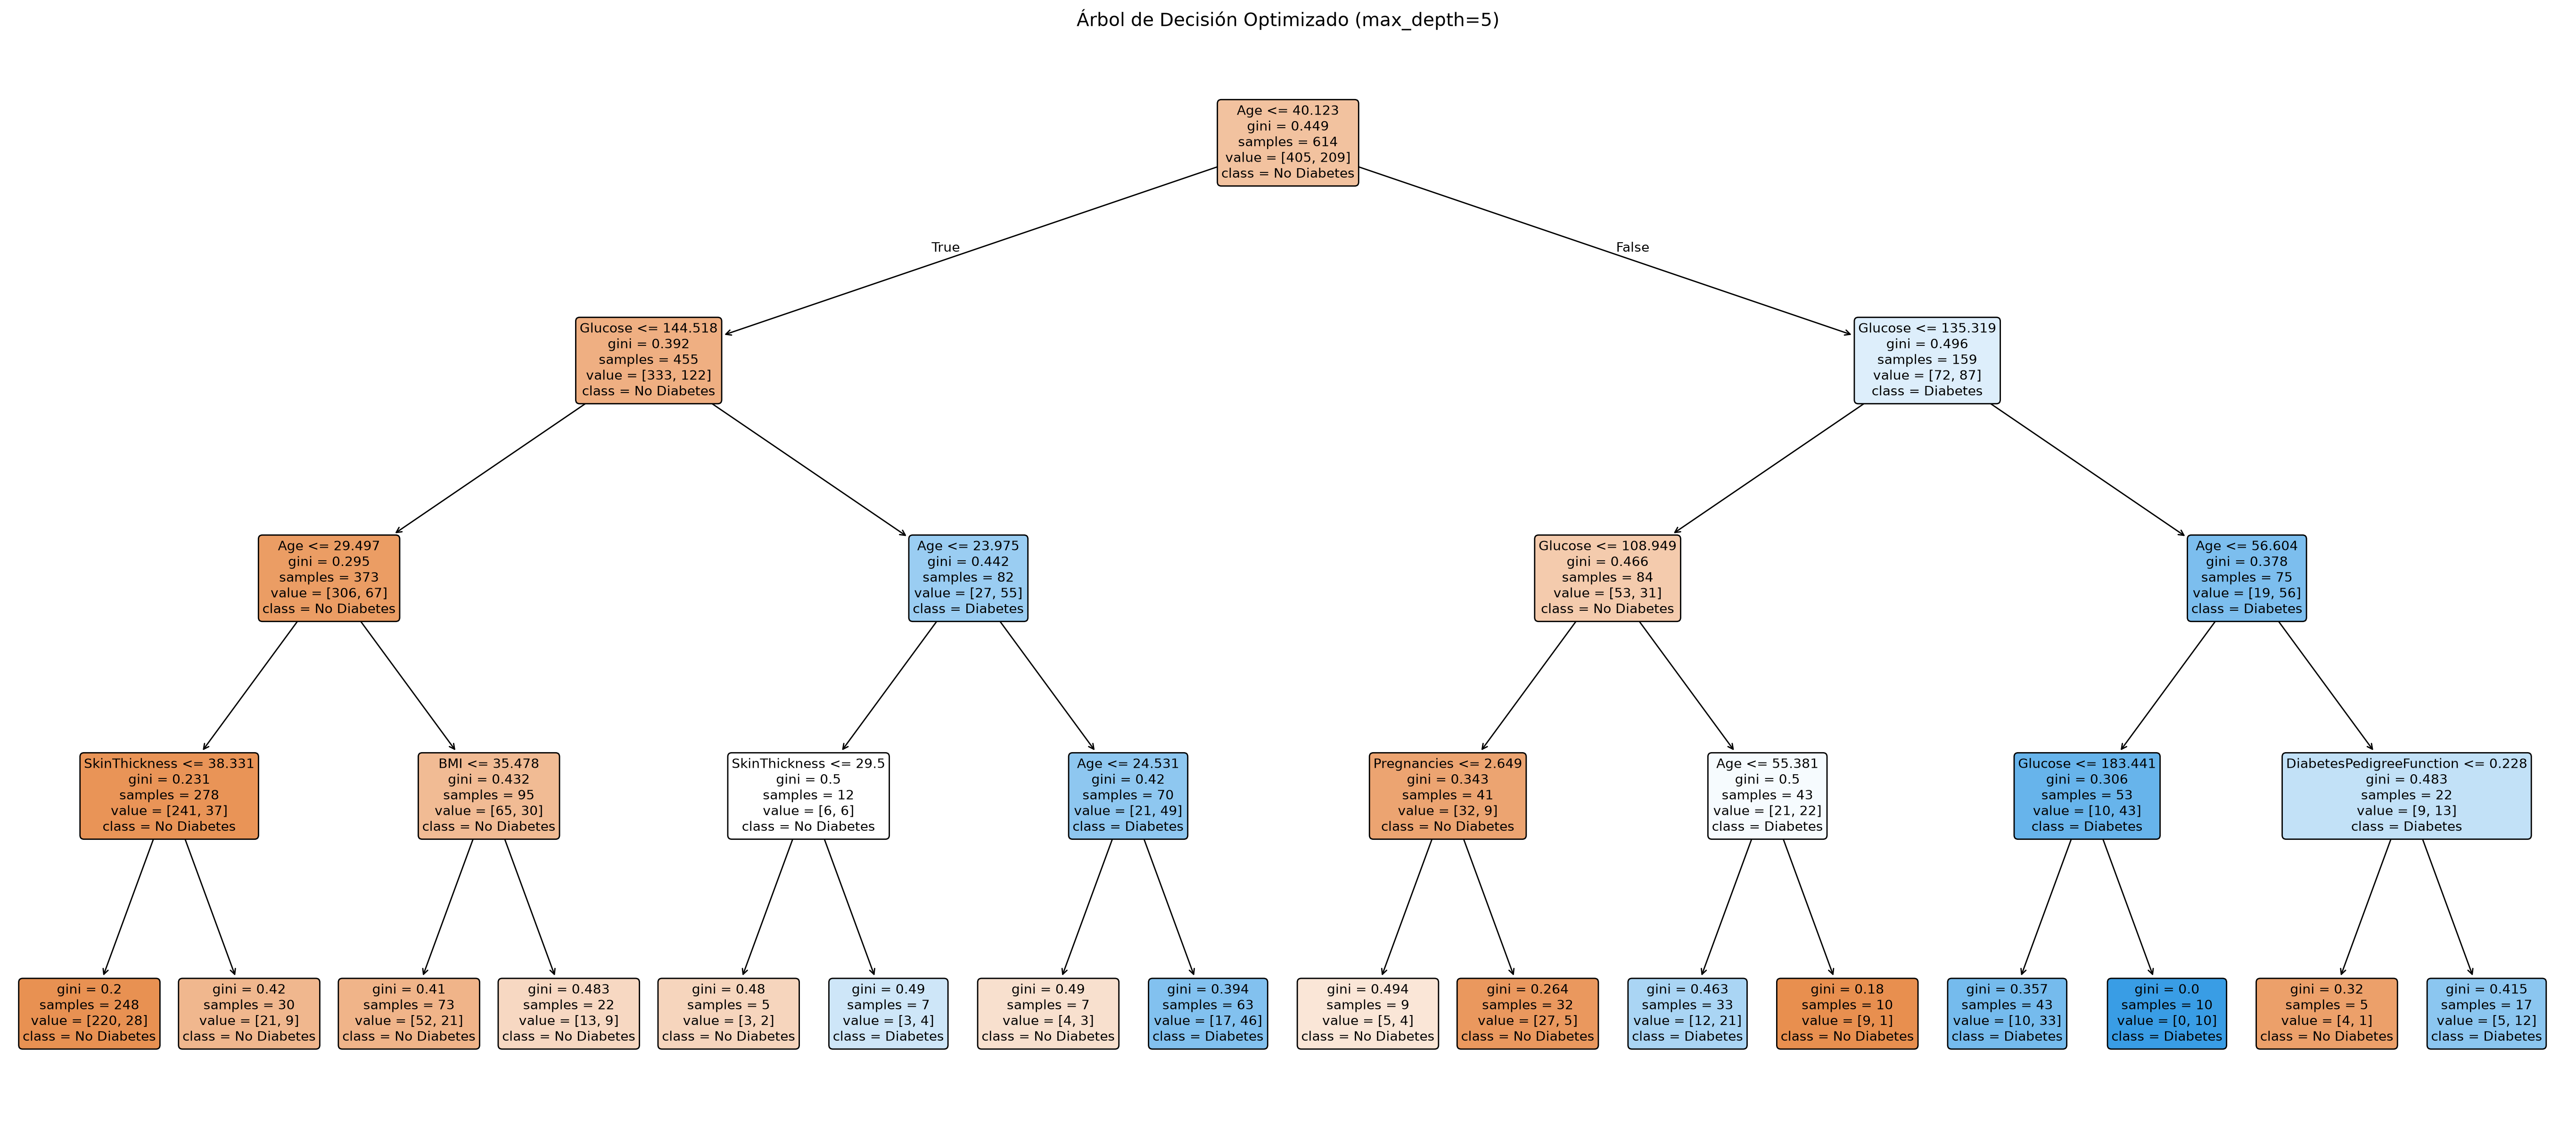

In [34]:
plt.figure(figsize=(35, 15), dpi=200)

# Graficamos el árbol definitivo
plot_tree(grid_search.best_estimator_,feature_names=X_train_CON_outliers.columns,class_names=["No Diabetes", "Diabetes"],filled=True,rounded=True,fontsize=10)

plt.title("Árbol de Decisión Optimizado (max_depth=5)", fontsize=14)
plt.show()

### Conclusiones:
- El análisis comparativo del Árbol de Decisión sobre el dataset demuestra que, si bien un modelo base puede alcanzar una exactitud en test (0.7338) pero en train evidencia un severo sobreajuste (1.000). 
- Al aplicar una optimización de hiperparámetros mediante GridSearchCV, se logra un modelo que reduce drásticamente la brecha de rendimiento, estabilizando el comportamiento predictivo aunque arroje una exactitud en test ligeramente más conservadora (0.6753). 
- Por tal razón se recomiendo realizar un random forest.